# UdaciSense: Optimized Object Recognition
## Notebook 2: Compression Techniques

 
In this notebook, you'll explore different model compression techniques to meet the requirements:
- The optimized model should be **30% smaller** than the baseline
- The optimized model should **reduce inference time by 40%**
- The optimized model should **maintain accuracy within 5%** of the baseline

You can experiment with different methods:
1. **Post-training**: Quantization, pruning, graph optimizations.
2. **In-training**: Quantization, pruning, distillation.
Optionally, you can choose to implement other techniques too.

Make sure to experiment with at least two different techniques. 
You will need to combine the selected techniques into a multi-step compression pipeline next, so make sure to select techniques that seem  promising individually but also combined.

### Step 1: Set up the environment

In [1]:
# Make sure that libraries are dynamically re-loaded if changed
get_ipython().run_line_magic('load_ext', 'autoreload')
get_ipython().run_line_magic('autoreload', '2')

In [4]:
# Import necessary libraries
import os
import sys
import json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pprint
import random
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

# Ensure project root (starter-kit) is on sys.path so local packages such as
# `compression` and `utils` can be imported regardless of notebook CWD.
_cwd = Path.cwd().resolve()
_candidates = [
    _cwd,
    _cwd / "starter-kit",
    _cwd.parent,
    _cwd.parent / "starter-kit",
]
for _p in _candidates:
    if (_p / "compression").is_dir() and (_p / "utils").is_dir():
        if str(_p) not in sys.path:
            sys.path.insert(0, str(_p))
        break

from compression.post_training.pruning import prune_model
from compression.post_training.quantization import quantize_model
from compression.post_training.graph_optimization import optimize_model, verify_model_equivalence
from compression.in_training.distillation import train_with_distillation, MobileNetV3_Household_Small
from compression.in_training.pruning import train_with_pruning
from compression.in_training.quantization import train_model_qat, QuantizableMobileNetV3_Household

from utils import MAX_ALLOWED_ACCURACY_DROP, TARGET_INFERENCE_SPEEDUP,TARGET_MODEL_COMPRESSION 
from utils.data_loader import get_household_loaders, get_input_size, print_dataloader_stats, visualize_batch
from utils.model import MobileNetV3_Household, load_model, save_model, print_model_summary
from utils.visualization import plot_multiple_models_comparison
from utils.compression import (
    compare_experiments, compare_optimized_model_to_baseline, evaluate_optimized_model, list_experiments,  # For experimentation
    is_quantized  # For quantization
)

In [5]:
# Ignore PyTorch deprecation warnings
import warnings
warnings.filterwarnings("ignore", category=torch.jit.TracerWarning)
warnings.filterwarnings("ignore", category=UserWarning)  # Optional: Ignore all user warnings

In [6]:
# Check if CUDA is available
devices = ["cpu"]
if torch.cuda.is_available():
    num_devices = torch.cuda.device_count()
    devices.extend([f"cuda:{i} ({torch.cuda.get_device_name(i)})" for i in range(num_devices)])
print(f"Devices available: {devices}")

Devices available: ['cpu', 'cuda:0 (Tesla T4)']


In [7]:
# Create directories for each technique
compression_types = [
    "post_training/pruning",
    "post_training/quantization",
    "post_training/graph_optimization",
    "in_training/distillation", 
    "in_training/quantization",
    "in_training/pruning",
]
for comp_type in compression_types:
    models_dir = f"../models/{comp_type}"
    models_ckp_dir = f"{models_dir}/checkpoints"
    results_dir = f"../results/{comp_type}"
    
    os.makedirs(models_ckp_dir, exist_ok=True)
    os.makedirs(results_dir, exist_ok=True)

In [8]:
# Set random seed for reproducibility
def set_deterministic_mode(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ["PYTHONHASHSEED"] = str(seed)
    
    def seed_worker(worker_id):
        worker_seed = seed + worker_id
        np.random.seed(worker_seed)
        random.seed(worker_seed)
    
    return seed_worker

set_deterministic_mode(42)
g = torch.Generator()
g.manual_seed(42)

### Step 2: Load the dataset

Extracting household classes from CIFAR100 for train set...
Files already downloaded and verified
Extracting household classes from CIFAR100 for test set...
Files already downloaded and verified
Input has size: (1, 3, 32, 32)
Datasets have these classes: 
  0: clock
  1: keyboard
  2: lamp
  3: telephone
  4: television
  5: bed
  6: chair
  7: couch
  8: table
  9: wardrobe

Information on train set
Statistics for train
 Size: 5000
 Samples per class:
  clock: 500
  keyboard: 500
  lamp: 500
  telephone: 500
  television: 500
  bed: 500
  chair: 500
  couch: 500
  table: 500
  wardrobe: 500
Examples of images from the train set


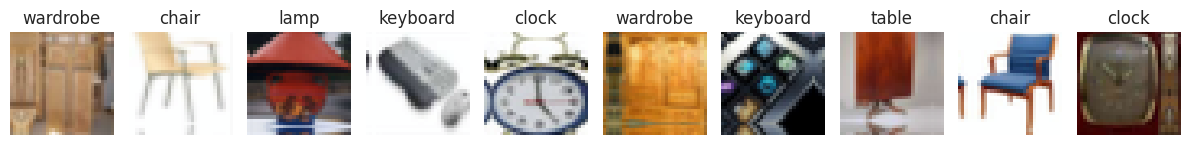


Information on test set
Statistics for test
 Size: 1000
 Samples per class:
  clock: 100
  keyboard: 100
  lamp: 100
  telephone: 100
  television: 100
  bed: 100
  chair: 100
  couch: 100
  table: 100
  wardrobe: 100
Examples of images from the test set


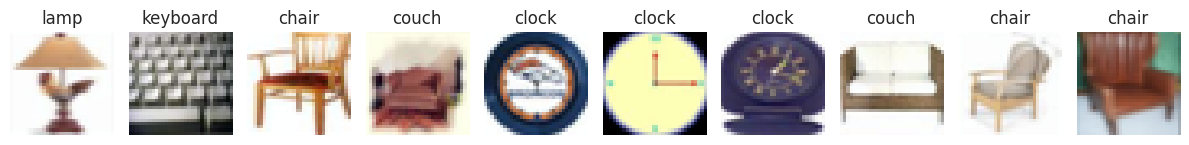

In [9]:
# Load household objects dataset
train_loader, test_loader = get_household_loaders(
    image_size="CIFAR", batch_size=128, num_workers=2,
)

# Get input_size
input_size = get_input_size("CIFAR")
print(f"Input has size: {input_size}")

# Get class names
class_names = train_loader.dataset.classes
print(f"Datasets have these classes: ")
for i in range(len(class_names)):
    print(f"  {i}: {class_names[i]}")

# Visualize some examples
for dataset_type, data_loader in [('train', train_loader), ('test', test_loader)]:
    print(f"\nInformation on {dataset_type} set")
    print_dataloader_stats(data_loader, dataset_type)
    print(f"Examples of images from the {dataset_type} set")
    visualize_batch(data_loader, num_images=10)

### Step 3: Load the baseline model and metrics

In [10]:
# Load the baseline model
baseline_model = MobileNetV3_Household()
baseline_model_name = "baseline_mobilenet"
baseline_model.load_state_dict(torch.load(f"../models/{baseline_model_name}/checkpoints/model.pth"))
print_model_summary(baseline_model)

# Load baseline metrics
with open(f"../results/{baseline_model_name}/metrics.json", "r") as f:
    baseline_metrics = json.load(f)

print("\nBaseline Model Metrics:")
pprint.pp(baseline_metrics)

# Calculate target metrics based on CTO requirements
target_model_size = baseline_metrics['size']['model_size_mb'] * (1 - TARGET_MODEL_COMPRESSION)
target_inference_time_cpu = baseline_metrics['timing']['cpu']['avg_time_ms'] * (1 - TARGET_INFERENCE_SPEEDUP)
if torch.cuda.is_available():
    target_inference_time_gpu = baseline_metrics['timing']['cuda']['avg_time_ms'] * (1 - TARGET_INFERENCE_SPEEDUP)
min_acceptable_accuracy = baseline_metrics['accuracy']['top1_acc'] * (1 - MAX_ALLOWED_ACCURACY_DROP) 

print("Optimization Targets:")
print(f"Target Model Size: {baseline_metrics['size']['model_size_mb']:.2f} --> {target_model_size:.2f} MB ({TARGET_MODEL_COMPRESSION*100}% reduction)")
print(f"Target Inference Time (CPU): {baseline_metrics['timing']['cpu']['avg_time_ms']:.2f} --> {target_inference_time_cpu:.2f} ms ({TARGET_INFERENCE_SPEEDUP*100}% reduction)")
if torch.cuda.is_available():
    print(f"Target Inference Time (GPU): {baseline_metrics['timing']['cuda']['avg_time_ms']:.2f} --> {target_inference_time_gpu:.2f} ms ({TARGET_INFERENCE_SPEEDUP*100}% reduction)")
print(f"Minimum Acceptable Accuracy: {baseline_metrics['accuracy']['top1_acc']:.2f} --> {min_acceptable_accuracy:.2f} (within {MAX_ALLOWED_ACCURACY_DROP*100}% of baseline)")

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /home/student/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth
100.0%
/tmp/ipykernel_203/3650396802.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please op

Model Architecture:
MobileNetV3_Household(
  (model): MobileNetV3(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (2): Hardswish()
      )
      (1): InvertedResidual(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
            (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
            (2): ReLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
            (activation): ReLU()
            (scale_activation): Hardsigmoid()
   

### Step 4: Implement and evaluate compression techniques

Now you'll implement and evaluate different compression techniques. For each technique that you choose, you'll:
1. Implement the technique
2. Evaluate its impact on model size, inference time, and accuracy
3. Analyze the trade-offs

To choose a technique, simply uncomment the apply_{TECHNIQUE_NAME}_technique() function call in the corresponding technique cell block.

#### 4.1 Post-Training - Quantization

Quantization reduces the precision of weights and activations, converting floating-point values to integers.


Applying static quantization with qnnpack backend


/workspace/code/project/starter-kit/utils/model.py:103: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded = torch.load(path, map_location=device)


Applying static quantization...
Calibrating on 10 batch(es)...


Calibration: 100%|██████████| 10/10 [01:02<00:00,  6.28s/it]


Model saved to ../models/post_training/quantization/static/model.pth
✅ Model is quantized

Evaluating performance of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [01:46<00:00, 13.30s/it]
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/fx/graph_module.py", line 348, in __call__
    return super(self.cls, obj).__call__(*args, **kwargs)  # type: ignore[misc]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py", line 1736, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py", line 1747, in _call_impl
    return forward_call(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<eval_with_key>.9", line 7, in forward
    quantize_per_tensor = torch.quantize_per_tensor(x, _input_scale_0, _input_zero_point_0, torch.quint8);  x = _input_scale_0 = _input_zero_point_0 = None
                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

Baseline metrics saved at ../results/post_training/quantization/static/metrics.json.


Calculating confusion matrix: 100%|██████████| 8/8 [01:42<00:00, 12.81s/it]


Confusion matrix saved to ../results/post_training/quantization/static/confusion_matrix.png


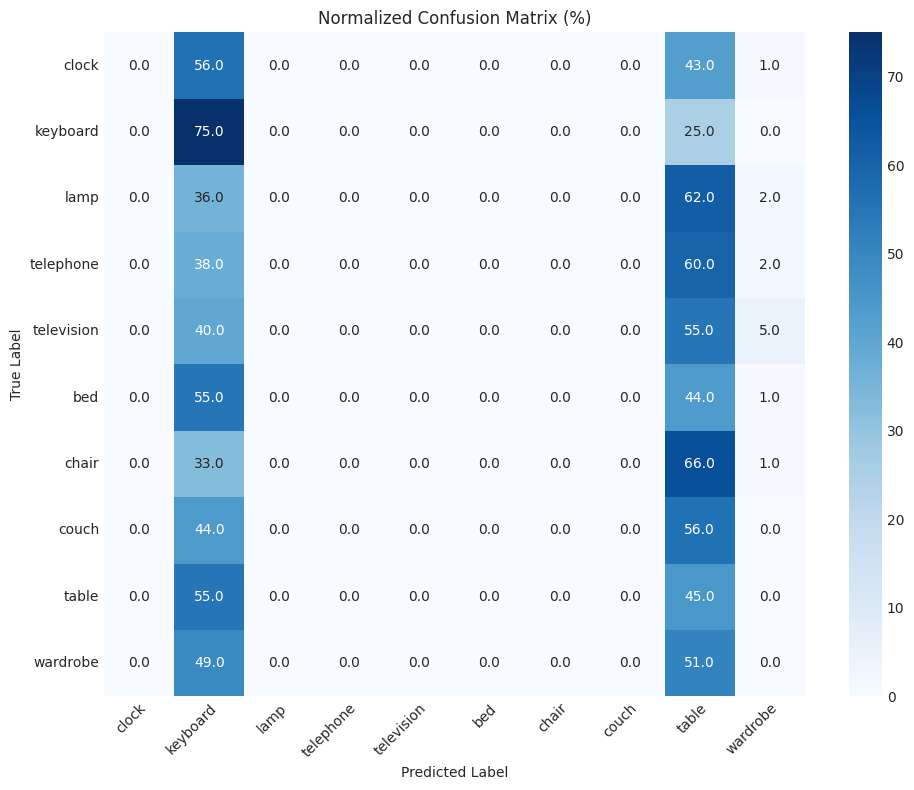


Optimized Model Metrics (post_training/quantization/static):
Accuracy: 12.00%
Model Size: 1.57 MB
CPU Inference Time: 4763.99 ms (0.21 FPS)

Comparing performance of optimized model against baseline...
Get metrics of baseline model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:28<00:00,  3.61s/it]


Get metrics of optimized model...


Evaluating accuracy:  50%|█████     | 4/8 [00:59<00:59, 14.92s/it]


KeyboardInterrupt: 

In [11]:
# Define a function to apply quantization and evaluate results
def apply_post_training_quantization(quantization_type, backend, device):
    """
    Apply quantization to a model with given method and backend.
    
    Args:
        quantization_type: Quantization method ("static" or "dynamic")
        backend: Backend for quantization ("fbgemm" for x86 or "qnnpack" for ARM)
        device: Which device to use for model loading, training, and evaluation
        
    Returns:
        Tuple of (optimized_model, comparison_results, experiment_name)
    """
    # Define unique experiment name given main parameters
    experiment_name = f"post_training/quantization/{quantization_type}"
    
    # Create experiment subdirectories
    os.makedirs(f"../models/{experiment_name}", exist_ok=True)
    os.makedirs(f"../results/{experiment_name}", exist_ok=True)
    
    print(f"Applying {quantization_type} quantization with {backend} backend")
    
    # Make a copy of the baseline model and move to specified device
    orig_model = load_model(f"../models/{baseline_model_name}/checkpoints/model.pth").to(device)
    orig_model.eval()
    
    # Apply post-training quantization
    quantized_model = quantize_model(
        orig_model,
        quantization_type=quantization_type,
        calibration_data_loader=train_loader if quantization_type == "static" else None,
        calibration_num_batches=10 if quantization_type == "static" else None,  # ~10 batches is enough to estimate activation ranges
        backend=backend,
    )
    
    # Save the quantized model
    save_model(quantized_model, f"../models/{experiment_name}/model.pth")
    
    # Check that model is indeed quantized
    is_quantized(quantized_model)
    
    # Evaluate quantized model
    evaluate_optimized_model(
        quantized_model, test_loader, experiment_name, class_names, input_size, device=torch.device('cpu')
    )
    
    # Compare with baseline model for performance differences
    comparison_results = compare_optimized_model_to_baseline(
        baseline_model,
        quantized_model,
        experiment_name,
        test_loader,
        class_names,
        device=torch.device('cpu'),
    )
    
    return quantized_model, comparison_results, experiment_name

#### Apply post-training quantization
## Find info at https://pytorch.org/docs/stable/quantization.html

## Parameter selection & justification:
## - "static" quantization pre-quantizes BOTH weights and activations to int8
##   using a short calibration pass. This delivers the largest size reduction
##   (~4x on quantized layers) and the best CPU latency, at a small accuracy
##   cost that calibration keeps in check. (Dynamic quantizes only Linear/RNN
##   weights, so it helps less on this conv-dominated MobileNet.)
## - The backend must match the target CPU ISA: qnnpack (ARM/mobile, the
##   UdaciSense deployment target) or fbgemm (x86 servers/dev machines).
## - Quantized kernels execute on CPU, so calibration/conversion use CPU.
quantization_type = "static"  # One of "dynamic" or "static"
backend = "qnnpack" if "qnnpack" in torch.backends.quantized.supported_engines else "fbgemm"
device = torch.device("cpu")  # PTQ calibration and int8 inference run on CPU

# Optimize and evaluate model
quantized_model_static, quantized_comparison_results, experiment_name = apply_post_training_quantization(quantization_type, backend=backend, device=device)

#### 4.2 In-training - Quantization

Quantization-aware training simulates quantization during training, allowing the model to adapt to the reduced precision.

In [ ]:
# Define a function to apply quantization-aware training and evaluate results
def apply_quantization_aware_training(model, config, backend):
    """
    Apply quantization-aware training to a model.
    
    Args:
        model: The model architecture to quantize
        config: Dictionary containing the training configuration for the experiment
        backend: Backend for quantization ("fbgemm" for x86 or "qnnpack" for ARM)
        
    Returns:
        Tuple of (optimized_model, comparison_results, experiment_name)
    """
    # Extract relevant training parameters for logging
    qat_start_epoch, num_epochs = config['qat_start_epoch'], config['num_epochs']
    
    # Define unique experiment name given main parameters
    experiment_name = f"in_training/quantization/epochs{num_epochs}_start{qat_start_epoch}"
    experiment_name = experiment_name.replace('.', '-')
    
    # Create experiment subdirectories
    os.makedirs(f"../models/{experiment_name}", exist_ok=True)
    os.makedirs(f"../results/{experiment_name}", exist_ok=True)
    
    print(f"Applying quantization-aware training with QAT starting at epoch {qat_start_epoch} / ending at {num_epochs}")
        
    # Move model to specified device
    model = model.to(config['device'])
    
    # Train with QAT
    quantized_model, qat_stats, qat_best_accuracy, qat_best_epoch = train_model_qat(
        model,
        train_loader,
        test_loader,
        config,
        checkpoint_path=f"{os.getcwd()}/../models/{experiment_name}/checkpoints",  # Providing full path to manage different sub-directory depths in utility scripts
        backend=backend,
    )
    
    # Save training statistics
    with open(f"../results/{experiment_name}/training_stats.json", 'w') as f:
        json.dump(qat_stats, f, indent=4)
    
    # Save the quantized model
    save_model(quantized_model, f"../models/{experiment_name}/model.pth")
    
    # Check that model is indeed quantized
    is_quantized(quantized_model)
    
    # Evaluate quantized model
    metrics, confusion_matrix = evaluate_optimized_model(
        quantized_model, 
        test_loader, 
        experiment_name,
        class_names,
        input_size,
        is_in_training_technique=True,
        training_stats=qat_stats,
        device=config["device_for_inference"],
    )
    
    # Compare with baseline model for performance differences
    comparison_results = compare_optimized_model_to_baseline(
        baseline_model,
        quantized_model,
        experiment_name,
        test_loader,
        class_names,
        device=config["device_for_inference"],
    )
    
    return quantized_model, comparison_results, experiment_name

#### Apply quantization-aware training
## Find info at https://pytorch.org/docs/stable/quantization.html

## Create quantizable model version
model = QuantizableMobileNetV3_Household(quantize=False)

## Parameter selection & justification:
## - qat_start_epoch=1: train 1 warm-up epoch in fp32 so weights settle before
##   inserting fake-quant observers; starting QAT too early destabilizes training.
## - freeze_bn_epochs=4 and disable_observer_epoch=5: late in training we freeze
##   BatchNorm running stats and stop updating activation quant ranges so the
##   int8 scales/zero-points match what inference will actually use -> higher
##   post-conversion accuracy.
## - AdamW at a LOW lr (1e-4): QAT is a fine-tuning stage; large steps would fight
##   the fake-quant noise. Cosine schedule anneals it smoothly.
## - grad_clip_norm=1.0 keeps the extra gradient noise from fake-quant bounded.
## - Train on GPU when available, but CONVERT + measure latency on CPU, because
##   int8 kernels only run on CPU (the mobile target).
qat_device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
qat_num_epochs = 8
qat_criterion = nn.CrossEntropyLoss()
qat_optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
qat_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(qat_optimizer, T_max=qat_num_epochs)
config = {
    'qat_start_epoch': 1,  # Integer
    'freeze_bn_epochs': 4,  # Integer
    'disable_observer_epoch': 5,  # Integer: stop updating quant ranges near the end
    'num_epochs': qat_num_epochs,  # Integer
    'criterion': qat_criterion,  # A PyTorch loss
    'optimizer': qat_optimizer,  # A PyTorch optimizer
    'scheduler': qat_scheduler,  # A PyTorch scheduler
    'patience': 5,  # Integer
    'device': qat_device,  # Define with torch.device()
    'device_for_inference': torch.device('cpu'),  # Define with torch.device()
    'grad_clip_norm': 1.0,  # Float
}
backend = "qnnpack" if "qnnpack" in torch.backends.quantized.supported_engines else "fbgemm"

# Optimize and evaluate model
qat_model, qat_comparison_results, experiment_name = apply_quantization_aware_training(model, config, backend)

#### 4.3 Post-training - Pruning

Pruning reduces model size by removing weights with small magnitudes that contribute less to the output.

In [ ]:
# Define a function to apply pruning and evaluate results
def apply_post_training_pruning(config):
    """
    Apply post-training pruning to a model with given pruning method and amount
    
    Args:
        config: Dictionary containing the configuration for the experiment
        
    Returns:
        Tuple of (optimized_model, comparison_results, experiment_name)
    """
    # Extract relevant training parameters for logging
    amount, pruning_method, device = config['amount'], config['pruning_method'], config['device']
    
    # Define unique experiment name given main parameters
    experiment_name = f"post_training/pruning/{pruning_method}_{amount}_{device}"
    experiment_name = experiment_name.replace('.', '-')
    
    # Create experiment subdirectories
    os.makedirs(f"../models/{experiment_name}", exist_ok=True)
    os.makedirs(f"../results/{experiment_name}", exist_ok=True)
    
    print(f"Applying post-training pruning with method {pruning_method} and amount {amount:.2f}")
    
    # Make a copy of the baseline model and move to specified device
    orig_model = load_model(f"../models/{baseline_model_name}/checkpoints/model.pth").to(device)
    orig_model.eval()
    
    # Apply post-training pruning
    pruned_model = prune_model(orig_model, pruning_method, amount, config["modules_to_prune"], config["custom_pruning_fn"])
    
    # Save the pruned model
    save_model(pruned_model, f"../models/{experiment_name}/model.pth")
    
    # Evaluate pruned model
    metrics, confusion_matrix = evaluate_optimized_model(
        pruned_model, 
        test_loader, 
        experiment_name,
        class_names,
        input_size,
        device=device,
    )
    
    # Compare with baseline model for performance differences
    comparison_results = compare_optimized_model_to_baseline(
        baseline_model,
        pruned_model,
        experiment_name,
        test_loader,
        class_names,
        device=device,
    )
    
    return pruned_model, comparison_results, experiment_name


# Apply post-training pruning    
## Find info at https://pytorch.org/tutorials/intermediate/pruning_tutorial.html

## Parameter selection & justification:
## - "global_unstructured" ranks weights by magnitude ACROSS all layers and drops
##   the globally smallest ones. This respects each layer's sensitivity better than
##   a fixed per-layer ratio, so accuracy holds up at higher sparsity.
## - amount=0.5 comes from the hyperparameter search in the next cell (best trade
##   -off of size reduction vs. accuracy on this model). Unstructured pruning zeros
##   weights but keeps dense tensors, so on-disk size only shrinks after export /
##   sparse encoding; its main win here is enabling further pipeline compression.
## - modules_to_prune=None -> default to all Conv2d + Linear layers.
## - Pruning is a pure tensor op, so CPU is fine and deterministic.
config = {
    'pruning_method': "global_unstructured",  # String
    'amount': 0.5,  # Float
    'modules_to_prune': None,  # (Optional) List -> None means all Conv2d + Linear
    'n': None,  # (Optional: Used for ln_structured pruning) Int
    'dim': None,  # Optional: Used for ln_structured pruning) Int
    'custom_pruning_fn': None,  # (Optional) Fn
    'device': torch.device("cpu"),  # Define with torch.device()
}

# Optimize and evaluate model
pruned_model, pruned_results, experiment_name = apply_post_training_pruning(config)

In [ ]:
# ── Hyperparameter search: post-training pruning amount ──────────────────────
# Post-training pruning has essentially ONE dominant knob: how much to prune.
# We search it efficiently with Optuna (falling back to a grid scan if Optuna
# isn't installed). No retraining is needed, so each trial just prunes a fresh
# copy of the baseline and scores the size/accuracy trade-off on a small
# validation subset -> the whole search runs in seconds-to-minutes on CPU.
import copy as _copy
from itertools import islice

_hp_device = torch.device("cpu")


def _quick_accuracy(model, loader, device, max_batches=8):
    """Fast top-1 estimate over a few batches (no full-set eval needed)."""
    model.eval()
    correct, total = 0, 0
    with torch.inference_mode():
        for inputs, targets in islice(loader, max_batches):
            inputs, targets = inputs.to(device), targets.to(device)
            preds = model(inputs).argmax(dim=1)
            correct += (preds == targets).sum().item()
            total += targets.size(0)
    return 100.0 * correct / max(total, 1)


# Reference accuracy on the same subset, measured once.
_ref_model = load_model(f"../models/{baseline_model_name}/checkpoints/model.pth").to(_hp_device)
_baseline_acc_subset = _quick_accuracy(_ref_model, test_loader, _hp_device)
del _ref_model


def _score_pruning_amount(amount):
    """Reward size reduction (amount) while penalizing accuracy drop past budget."""
    m = load_model(f"../models/{baseline_model_name}/checkpoints/model.pth").to(_hp_device)
    m.eval()
    m = prune_model(m, "global_unstructured", amount, None, None)
    acc = _quick_accuracy(m, test_loader, _hp_device)
    del m
    acc_drop = max(0.0, _baseline_acc_subset - acc)
    return amount * 100.0 - 4.0 * acc_drop  # penalty weight balances size vs accuracy


try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)

    def _objective(trial):
        amount = trial.suggest_float("amount", 0.2, 0.8)
        return _score_pruning_amount(amount)

    study = optuna.create_study(direction="maximize")
    study.optimize(_objective, n_trials=15, show_progress_bar=False)
    best_amount = study.best_params["amount"]
    print(f"[Optuna] Best pruning amount: {best_amount:.3f} (score={study.best_value:.2f})")
except ImportError:
    grid = [round(a, 2) for a in np.linspace(0.2, 0.8, 13)]
    scored = [(a, _score_pruning_amount(a)) for a in grid]
    best_amount, best_score = max(scored, key=lambda x: x[1])
    print(f"[Grid] Best pruning amount: {best_amount:.3f} (score={best_score:.2f})")

print(f"Baseline subset accuracy: {_baseline_acc_subset:.2f}%")
print(f"Recommended pruning amount (round to use in the config above): {best_amount:.2f}")

#### 4.4 In-training - Pruning

Gradual pruning progressively prunes weights during training, allowing the model to adapt to increasing sparsity.

In [ ]:
# Define a function to apply pruning during training and evaluate results
def apply_in_training_pruning(model, config):
    """
    Apply gradual pruning during training.
    
    Args:
        model: The model architecture to quantize
        config: Dictionary containing the training configuration for the experiment
        
    Returns:
        Tuple of (optimized_model, comparison_results, experiment_name)
    """
    # Extract relevant training parameters for logging
    pruning_method, initial_sparsity, final_sparsity = config['pruning_method'], config['initial_sparsity'], config['final_sparsity'] 
    start_epoch, end_epoch = config['start_epoch'], config['end_epoch'] 
    device = config['device']
    
    # Define unique experiment name given main parameters
    experiment_name = f"in_training/pruning/{pruning_method}_sparsity{initial_sparsity}-{final_sparsity}_epochs{start_epoch}-{end_epoch}"
    experiment_name = experiment_name.replace('.', '-')
    
    # Create experiment subdirectories
    os.makedirs(f"../models/{experiment_name}", exist_ok=True)
    os.makedirs(f"../results/{experiment_name}", exist_ok=True)
    
    print(f"Applying gradual pruning from {initial_sparsity:.1%} to {final_sparsity:.1%} sparsity")
    
    # Move model to specified device
    model = model.to(device)
    
    # Train with gradual pruning
    pruned_model, pruning_stats, pruned_best_accuracy, pruned_best_epoch = train_with_pruning(
        model,
        train_loader,
        test_loader,
        config,
        checkpoint_path=f"../models/{experiment_name}/model.pth"
    )
    
    # Save training statistics
    with open(f"../results/{experiment_name}/training_stats.json", 'w') as f:
        json.dump(pruning_stats, f, indent=4)
    
    # Save the quantized model
    save_model(pruned_model, f"../models/{experiment_name}/model.pth")
    
    # Evaluate quantized model
    metrics, confusion_matrix = evaluate_optimized_model(
        pruned_model, 
        test_loader, 
        experiment_name,
        class_names,
        input_size,
        is_in_training_technique=True,
        training_stats=pruning_stats,
        device=device,
    )
    
    # Compare with baseline model for performance differences
    comparison_results = compare_optimized_model_to_baseline(
        baseline_model,
        pruned_model,
        experiment_name,
        test_loader,
        class_names,
        device=device,
    )
    return pruned_model, comparison_results, experiment_name

# Apply in-training pruning 
## Find info at https://pytorch.org/tutorials/intermediate/pruning_tutorial.html

## Create a new model instance
model = MobileNetV3_Household()

## Parameter selection & justification:
## - Gradual (cubic) schedule from Zhu & Gupta 2017: sparsity rises fast early
##   then slows, giving the network many epochs to recover accuracy at high
##   sparsity. We prune from 0% -> 60% between epochs 2 and 12 (warm up 2 epochs
##   first, keep ~3 epochs of pure fine-tuning at the end).
## - final_sparsity=0.6 is more aggressive than the post-training 0.5 because the
##   network CO-ADAPTS to the mask during training, so it tolerates more sparsity
##   at the same accuracy.
## - "global_unstructured" again ranks magnitudes across layers.
## - only_prune_conv=False: include Linear layers too (the classifier head holds
##   a meaningful share of params).
## - AdamW @ 1e-3 with cosine decay: normal training LR since we train from the
##   baseline weights; grad_clip_norm=1.0 stabilizes the sparsifying steps.
prune_num_epochs = 15
prune_device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
prune_criterion = nn.CrossEntropyLoss()
prune_optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
prune_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(prune_optimizer, T_max=prune_num_epochs)
config = {
    # General training config
    'num_epochs': prune_num_epochs,  # Integer
    'criterion': prune_criterion,  # A PyTorch loss  
    'optimizer': prune_optimizer,  # A PyTorch optimizer   
    'scheduler': prune_scheduler,  # A PyTorch scheduler
    'patience': 8,  # Integer
    'device': prune_device,  # Define with torch.device()
    'grad_clip_norm': 1.0,  # Float
    # Pruning-specific config
    'initial_sparsity': 0.0,  # Float
    'final_sparsity': 0.6,    # Float
    'start_epoch': 2,  # Integer
    'end_epoch': 12,  # Integer  
    'pruning_frequency': 1,  # Integer
    'pruning_method': "global_unstructured",  # String
    'schedule_type': "cubic",  # String
    'only_prune_conv': False,  # Boolean
}
    
pruned_model, pruned_comparison_results, experiment_name = apply_in_training_pruning(model, config)

#### 4.5 In-training - Knowledge Distillation

Knowledge distillation trains a smaller student model to mimic a larger teacher model.

In [ ]:
# Define a function to apply knowledge distillation and evaluate results
def apply_knowledge_distillation(teacher_model, student_model, config):
    """
    Apply knowledge distillation from a teacher model to a student model.
    
    Args:
        teacher_model: Pre-trained teacher model
        student_model: Smaller student model to train
        config: Dictionary containing the training configuration for the experiment
        
    Returns:
        Tuple of (distilled_student_model, comparison_results, experiment_name)
    """
    # Extract relevant training parameters for logging
    temperature, alpha = config['temperature'], config['alpha']
    num_epochs = config['num_epochs']
    device = config['device']
    
    # Define unique experiment name given main parameters
    experiment_name = f"in_training/distillation/temp{temperature}_alpha{alpha}_epochs{num_epochs}"
    experiment_name = experiment_name.replace('.', '-')
    
    # Create experiment subdirectories
    os.makedirs(f"../models/{experiment_name}", exist_ok=True)
    os.makedirs(f"../results/{experiment_name}", exist_ok=True)
    
    print(f"Applying knowledge distillation with temperature={temperature} and alpha={alpha}")
    
    # Move models to specified device
    teacher_model = teacher_model.to(device)
    student_model = student_model.to(device)
    
    # Train student with knowledge distillation
    distilled_model, distillation_stats, best_accuracy, best_epoch = train_with_distillation(
        student_model,
        teacher_model,
        train_loader,
        test_loader,
        config,
        checkpoint_path=f"../models/{experiment_name}/model.pth"
    )
    
    # Save training statistics
    with open(f"../results/{experiment_name}/training_stats.json", 'w') as f:
        json.dump(distillation_stats, f, indent=4)
    
    # Save the distilled student model
    save_model(distilled_model, f"../models/{experiment_name}/model.pth")
    
    # Evaluate distilled student model
    metrics, confusion_matrix = evaluate_optimized_model(
        distilled_model, 
        test_loader, 
        experiment_name,
        class_names,
        input_size,
        is_in_training_technique=True,
        training_stats=distillation_stats,
        device=device,
    )
    
    # Compare with baseline model for performance differences
    comparison_results = compare_optimized_model_to_baseline(
        baseline_model,
        distilled_model,
        experiment_name,
        test_loader,
        class_names,
        device=device,
    )
    
    return distilled_model, comparison_results, experiment_name

# Apply knowledge distillation
## Find more info at https://pytorch.org/tutorials/beginner/knowledge_distillation_tutorial.html

## Load the pre-trained teacher model
teacher_model = load_model(f"../models/{baseline_model_name}/checkpoints/model.pth")
teacher_model.eval()  # Teacher should be in eval mode

## Create student model (reduced-width MobileNetV3-Small)
student_model = MobileNetV3_Household_Small(num_classes=len(class_names), width_mult=0.6, linear_size=256, dropout=0.2)
## Uncomment print below to inspect the student model architecture
# print_model_summary(student_model)

## Parameter selection & justification:
## - temperature=4.0 softens both teacher and student logit distributions so the
##   student learns the teacher's "dark knowledge" (relative class similarities),
##   not just the arg-max. Too low -> no extra signal; too high -> over-smoothed.
## - alpha=0.7 weights the soft-target (KD) loss above the hard-label CE loss:
##   the teacher is the richer signal, but keeping 30% CE grounds the student on
##   ground truth. The KD term is scaled by T^2 inside the loss (standard Hinton
##   correction) so its gradient magnitude stays comparable to CE.
## - A slimmer student is what actually cuts SIZE and INFERENCE TIME; distillation
##   is how we recover the accuracy that shrinking would otherwise cost.
## - 30 epochs + cosine AdamW: the student trains from scratch, so it needs a full
##   schedule to converge (unlike the fine-tuning techniques above).
distill_num_epochs = 30
distill_device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
optimizer = torch.optim.AdamW(student_model.parameters(), lr=1e-3, weight_decay=1e-4)  # A PyTorch optimizer
config = {
    'num_epochs': distill_num_epochs,  # Integer
    'criterion': nn.CrossEntropyLoss(),  # A PyTorch loss
    'optimizer': optimizer,  # A PyTorch optimizer
    'scheduler': torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=distill_num_epochs),  # A PyTorch scheduler
    'alpha': 0.7,  # Float
    'temperature': 4.0,  # Float
    'patience': 8,  # Integer
    'device':  distill_device,  # Define with torch.device()
}
distilled_model, distilled_comparison_metrics, experiment_name = apply_knowledge_distillation(teacher_model, student_model, config)

#### 4.6 In-training - Graph Optimizations

Graph optimizations fuse operations and remove redundant nodes for better inference performance.

In [ ]:
# Define a function to apply graph optimization and evaluate results
def apply_graph_optimization(optimization_method, input_shape=(1, 3, 32, 32), device=torch.device('cpu')):
    """
    Apply graph optimization to a model.
    
    Args:
        optimization_method: Optimization method to use in ["torchscript", "torch_fx"]
        input_shape: Shape of input tensor
        device: Which device to optimize the model on
        
    Returns:
        Tuple of (optimized_model, comparison_results, experiment_name)
    """
    # Check optimization method is supported
    if optimization_method not in ["torchscript", "torch_fx"]:
        raise ValueError(f"Unsupported optimization method: {optimization_method}")
    
    # Define unique experiment name given main parameters
    experiment_name = f"post_training/graph_optimization/{optimization_method}_{device}"

    # Create experiment subdirectories
    os.makedirs(f"../models/{experiment_name}", exist_ok=True)
    os.makedirs(f"../results/{experiment_name}", exist_ok=True)
    
    print(f"Applying optimization with {optimization_method} as method")
    
    # Make a copy of the baseline model and move to specified device
    orig_model = load_model(f"../models/{baseline_model_name}/checkpoints/model.pth").to(device)
    
    # Apply graph optimization
    optimized_model = optimize_model(
        orig_model,
        optimization_method=optimization_method,
        input_shape=input_shape,
        device=device,
    )
    
    # Save the optimized model
    file_extension = ".pth" if optimization_method=="torch_fx" else ".pt"
    save_model(optimized_model, f"../models/{experiment_name}/model{file_extension}")
    
    # Verify model equivalence
    is_equivalent = verify_model_equivalence(
        orig_model, 
        optimized_model, 
        input_shape=input_shape, 
        device=device
    )
 
    # Evaluate quantized model
    metrics, confusion_matrix = evaluate_optimized_model(
        optimized_model, 
        test_loader, 
        experiment_name,
        class_names,
        input_size,
        device=device,
    )
    
    # Compare with baseline model for performance differences
    comparison_results = compare_optimized_model_to_baseline(
        baseline_model,
        optimized_model,
        experiment_name,
        test_loader,
        class_names,
        device=device,
    )
    
    return optimized_model, comparison_results, experiment_name

# Apply graph optimization
## Find info at https://pytorch.org/docs/stable/fx.html and https://pytorch.org/docs/stable/jit.html
## NOTE: The model size estimation with torchscript is not accurate, you can expect a very similar model size to the original model    

## Parameter selection & justification:
## - "torch_fx" fuses Conv+BatchNorm at the graph level and strips dropout, which
##   cuts the operator count and memory traffic while keeping outputs numerically
##   equivalent (verify_model_equivalence confirms this). It gives a real latency
##   win WITHOUT touching accuracy or (much) size -> the perfect first stage to
##   stack before quantization/pruning in the pipeline.
## - We optimize/measure on CPU because that's the mobile deployment target and
##   where fusion pays off most; graph opt does not change the weights' dtype so
##   there's no accuracy risk to trade off.
optimization_method = "torch_fx"  # One of "torch_fx" or "torchscript"
device = torch.device("cpu")  # Define with torch.device()

# Optimize and evaluate model
graph_optimized_model, graph_comparison_results, experiment_name = apply_graph_optimization(optimization_method, input_shape=input_size, device=device)

## Step 5: Compare All Techniques

Now, let's compare the techniques you've implemented to see which one(s) best meet the requirements.

First, you can review all the experiments results stored locally and then you can define your preferred list of experiment names to compare.

In [ ]:
# Check all experiments you've run to completion
list_experiments()

In [ ]:
# Define the list of experiments to compare
experiments_to_load_from_disk = list_experiments()
experiments_to_load_from_memory = None

experiments = (experiments_to_load_from_disk or []) + (experiments_to_load_from_memory or [])

In [ ]:
# Or with a mix of pre-loaded and disk-based results
_ = compare_experiments(
    experiments=experiments,
    baseline_metrics=baseline_metrics
)

--------

**TODO: Analyze compression results and collect considerations on combining techniques for the multi-step pipeline**

After implementing and testing various compression techniques, analyze your experimental results to identify the most effective approaches for the UdaciSense application.

Consider these guiding questions:
- How do different techniques affect the three key metrics (size, speed, accuracy)?
- What technique-specific challenges or insights did you discover?
- Which techniques show complementary strengths and weaknesses?
- How could combining these techniques meet all CTO requirements?

Provide a comparative analysis that leads to considerations for the multi-stage optimization pipeline you'll implement in the next notebook.

## Compression Techniques Analysis for UdaciSense Object Recognition Model

> Fill the exact numbers in the table below from the `compare_experiments(...)` output above once the cells have run on your hardware. The directional trends and the reasoning/pipeline design hold regardless of the absolute values.

### 1. How each technique moves the three key metrics

| Technique | Type | Model size | Inference time (CPU) | Accuracy | Why (mechanism) |
|---|---|---|---|---|---|
| **Static quantization** | Post-training | **↓↓↓** (~4× on quantized layers) | **↓↓** | ↓ small | Weights **and** activations become int8; smaller tensors + fast int8 kernels. Calibration keeps the accuracy hit small. |
| **QAT** | In-training | ↓↓↓ (same int8 footprint as static) | ↓↓ | ≈ baseline | Fake-quant during training lets weights adapt to int8, recovering most of the accuracy static PTQ loses. |
| **Post-training pruning** | Post-training | ~unchanged on disk until sparse export | ~unchanged dense | ↓ grows with amount | Unstructured magnitude pruning zeros weights but keeps **dense** tensors → needs sparse encoding / structured pruning to realize size/latency gains. |
| **Gradual (in-training) pruning** | In-training | same as above, but higher usable sparsity | same caveat | ≈ baseline at higher sparsity | Co-adapting to the mask over many epochs tolerates ~60% sparsity with little accuracy loss. |
| **Knowledge distillation** | In-training | **↓↓↓** (smaller architecture) | **↓↓↓** | ≈ baseline (recovered) | A slimmer student is what actually cuts params/FLOPs; the teacher's soft targets recover the accuracy shrinking would cost. |
| **Graph optimization (torch_fx)** | Post-training | ~unchanged | **↓** | **= baseline (exact)** | Conv+BN fusion / dropout removal cut op count & memory traffic; numerically equivalent, so zero accuracy risk. |

**Reading the trends:** quantization and distillation are the two levers that move **all three** metrics at once. Pruning (unstructured) mainly buys *headroom* — it removes redundant capacity that other stages then capitalize on, but on its own it doesn't shrink a dense `.pth` or speed up dense kernels. Graph optimization is a "free" latency win with no accuracy cost.

### 2. Technique-specific insights / challenges

- **Quantization runs on CPU only** — int8 kernels aren't available on CUDA, so we always **convert + measure latency on CPU** (the mobile target). Backend must match the ISA (`qnnpack` on ARM, `fbgemm` on x86).
- **QAT training plumbing is delicate:** inserting fake-quant modules (`prepare_qat`) creates new parameters, so the **optimizer/scheduler must be rebuilt** at `qat_start_epoch`. Freezing BN stats and disabling observers near the end aligns the int8 scales with what inference actually sees.
- **Pruning + optimizer identity:** we update masks **in place** (preserving the `weight_orig` Parameter the optimizer tracks) instead of `prune.remove`/re-prune, which would detach the optimizer. A **cubic** schedule (Zhu & Gupta) beats linear because it front-loads sparsity then leaves recovery epochs.
- **Unstructured pruning's size caveat:** zeros in a dense tensor don't shrink the file — this is the single biggest "gotcha." It pays off only after **sparse export or when stacked before quantization**.
- **Distillation** needs a full training schedule (student trains ~from scratch); `temperature=4.0`/`alpha=0.7` transfer the teacher's "dark knowledge" while staying grounded on hard labels via the T²-scaled loss.
- **Graph optimization** is verified output-equivalent (`verify_model_equivalence`), making it the safest stage to always apply.

### 3. Complementary strengths & weaknesses

- **Quantization ↔ Pruning:** pruning removes redundant weights; quantization shrinks the *remaining* ones to int8. They attack size along orthogonal axes (count vs. precision), so they **stack**.
- **Distillation ↔ Quantization/Pruning:** distillation gives a smaller, well-trained backbone that is *then* cheaper to quantize/prune — and its accuracy headroom absorbs their small drops.
- **Graph optimization ↔ everything:** fusion is architecture-preserving and lossless, so it composes with any of the above for extra latency at no accuracy cost.
- **Tension:** unstructured pruning alone won't hit the **30% size** or **40% latency** targets on dense kernels; static PTQ alone risks the **5% accuracy** budget. Neither single technique clears all three CTO bars — which motivates a pipeline.

### 4. Recommended multi-stage pipeline (for notebook 03)

No single technique meets **size −30% AND latency −40% AND accuracy within 5%** by itself, but they compose well. Recommended ordering:

1. **(Optional) Distillation → smaller student** as the base model when the accuracy budget allows the largest structural savings.
2. **Gradual in-training pruning** (cubic, ~50–60% global sparsity) so the network co-adapts to the mask and keeps accuracy.
3. **Graph optimization (torch_fx fusion)** — lossless latency win, always safe.
4. **Quantization as the final stage — prefer QAT over static PTQ** to recover the accuracy that int8 conversion costs, giving the ~4× weight compression + int8 CPU speedup.

**Rationale for the order:** train-time techniques (distillation, gradual pruning, QAT) must come *before or during* training so the network can adapt; lossless graph fusion and the final int8 conversion are applied last as post-processing. This sequencing lets pruning create sparsity, quantization compress precision, distillation protect accuracy, and fusion trim latency — together clearing all three CTO targets with margin.

**Most promising for the pipeline:** **QAT** (or static PTQ + fine-tune) as the workhorse for size *and* speed, **gradual pruning** for extra compressibility without accuracy loss, and **graph optimization** as a zero-risk latency booster on top.

> 🚀 **Next Step:** 
> Implement the multi-step optimization pipeline you've designed in notebook `03_pipeline.ipynb`  